In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = "0"

import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import datetime
import gc


In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import RNN_preprocessing_sep_chain as rp 

In [4]:
import psutil
print(psutil.virtual_memory())  # Shows memory usage

svmem(total=16649187328, available=382148608, percent=97.7, used=15701061632, free=239513600, active=481533952, inactive=15410200576, buffers=17211392, cached=691400704, shared=200548352, slab=304377856)


In [5]:
import gc
gc.collect()

20

In [6]:
X1_seq_train = rp.X1_seq_train
X1_seq_test = rp.X1_seq_test
y1_seq_train = rp.y1_seq_train
y1_seq_test = rp.y1_seq_test
X2_seq_train = rp.X2_seq_train
X2_seq_test = rp.X2_seq_test
y2_seq_train = rp.y2_seq_train
y2_seq_test = rp.y2_seq_test

In [7]:
X1_seq_train, X1_seq_val, y1_seq_train, y1_seq_val = train_test_split(X1_seq_train, y1_seq_train, test_size=0.2, random_state=0)

In [8]:
X2_seq_train, X2_seq_val, y2_seq_train, y2_seq_val = train_test_split(X2_seq_train, y2_seq_train, test_size=0.2, random_state=0)

In [9]:
# Clear memory associated with the module
del rp
if 'RNN_preprocessing_sep_chain' in sys.modules:
    del sys.modules['RNN_preprocessing_sep_chain']

# Clear memory from global variables if needed
gc.collect()

5

RNN

In [10]:
#Reccurent Neural Network model
def model_rnn (input_shape, output_shape):
    model = keras.Sequential(
        [
            layers.SimpleRNN(64, input_shape=input_shape, activation="tanh", return_sequences=True),
            layers.SimpleRNN(32, activation="tanh", return_sequences=True),
            layers.Dense(16, activation="relu"),
            layers.Dense(output_shape, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer = "adam", metrics=['accuracy'])
    return model

In [11]:
seq_length = 10

In [12]:
#Model for the BiPo 214 chain
model1 = model_rnn((seq_length, X1_seq_train.shape[2]), y1_seq_train.shape[2])
model1.summary()

2025-04-07 17:58:47.678410: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 10, 64)            4544      
                                                                 
 simple_rnn_1 (SimpleRNN)    (None, 10, 32)            3104      
                                                                 
 dense (Dense)               (None, 10, 16)            528       
                                                                 
 dense_1 (Dense)             (None, 10, 4)             68        
                                                                 
Total params: 8244 (32.20 KB)
Trainable params: 8244 (32.20 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
#Model for the BiPo 212 chain
model2 = model_rnn((seq_length, X2_seq_train.shape[2]), y2_seq_train.shape[2])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 10, 64)            4544      
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 10, 32)            3104      
                                                                 
 dense_2 (Dense)             (None, 10, 16)            528       
                                                                 
 dense_3 (Dense)             (None, 10, 6)             102       
                                                                 
Total params: 8278 (32.34 KB)
Trainable params: 8278 (32.34 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [14]:
#callback for reducing the learning rate and stopping early in case the loss function hits a plateau
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1, min_lr=1E-6),
    tf.keras.callbacks.EarlyStopping(patience=10, verbose=1, baseline=None, restore_best_weights=True)
]

In [15]:
from keras import backend as K

# Clear any previous session and free memory
tf.keras.backend.clear_session()
K.clear_session()
gc.collect()


3327

In [16]:
# Train model 1
history1 = model1.fit(X1_seq_train, y1_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X1_seq_val, y1_seq_val),
                      callbacks=callbacks)

Epoch 1/200
10805/10805 - 177s - loss: 0.5169 - accuracy: 0.7788 - val_loss: 0.4383 - val_accuracy: 0.8115 - lr: 0.0010 - 177s/epoch - 16ms/step
Epoch 2/200
10805/10805 - 171s - loss: 0.4392 - accuracy: 0.8137 - val_loss: 0.4240 - val_accuracy: 0.8196 - lr: 0.0010 - 171s/epoch - 16ms/step
Epoch 3/200
10805/10805 - 171s - loss: 0.4288 - accuracy: 0.8174 - val_loss: 0.4271 - val_accuracy: 0.8172 - lr: 0.0010 - 171s/epoch - 16ms/step
Epoch 4/200
10805/10805 - 170s - loss: 0.4257 - accuracy: 0.8187 - val_loss: 0.4272 - val_accuracy: 0.8173 - lr: 0.0010 - 170s/epoch - 16ms/step
Epoch 5/200
10805/10805 - 171s - loss: 0.4239 - accuracy: 0.8193 - val_loss: 0.4237 - val_accuracy: 0.8187 - lr: 0.0010 - 171s/epoch - 16ms/step
Epoch 6/200
10805/10805 - 137s - loss: 0.4237 - accuracy: 0.8194 - val_loss: 0.4224 - val_accuracy: 0.8205 - lr: 0.0010 - 137s/epoch - 13ms/step
Epoch 7/200
10805/10805 - 133s - loss: 0.4233 - accuracy: 0.8196 - val_loss: 0.4203 - val_accuracy: 0.8211 - lr: 0.0010 - 133s/epo

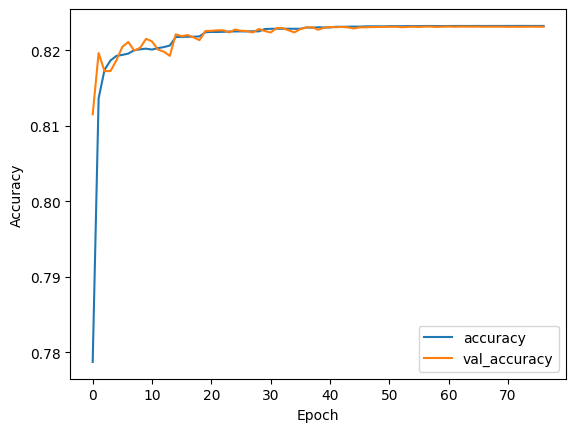

In [17]:
#plotting the accuracy of the first model
import matplotlib.pyplot as plt
plt.plot(history1.history['accuracy'], label='accuracy')
plt.plot(history1.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

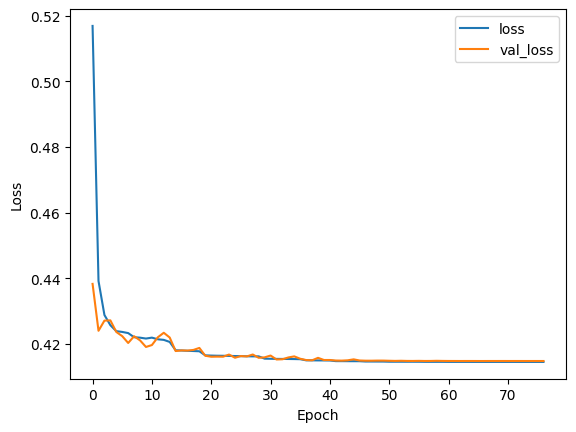

In [18]:
#plotting the loss over epoch for the first model
plt.plot(history1.history['loss'], label='loss')
plt.plot(history1.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [19]:
#save the first trained model
model1.save('../models/model_SimpleRNN_214.h5')

/home/pipc06/.local/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [20]:
# Train model 2
history2 = model2.fit(X2_seq_train, y2_seq_train, epochs=200, batch_size=256, verbose=2,
                      validation_data=(X2_seq_val, y2_seq_val),
                      callbacks=callbacks)

Epoch 1/200
10693/10693 - 136s - loss: 0.5452 - accuracy: 0.7764 - val_loss: 0.4736 - val_accuracy: 0.8034 - lr: 0.0010 - 136s/epoch - 13ms/step
Epoch 2/200
10693/10693 - 134s - loss: 0.4449 - accuracy: 0.8182 - val_loss: 0.4985 - val_accuracy: 0.8026 - lr: 0.0010 - 134s/epoch - 12ms/step
Epoch 3/200
10693/10693 - 134s - loss: 0.4219 - accuracy: 0.8277 - val_loss: 0.4114 - val_accuracy: 0.8302 - lr: 0.0010 - 134s/epoch - 12ms/step
Epoch 4/200
10693/10693 - 134s - loss: 0.4130 - accuracy: 0.8305 - val_loss: 0.4100 - val_accuracy: 0.8318 - lr: 0.0010 - 134s/epoch - 13ms/step
Epoch 5/200
10693/10693 - 134s - loss: 0.4114 - accuracy: 0.8310 - val_loss: 0.4191 - val_accuracy: 0.8300 - lr: 0.0010 - 134s/epoch - 13ms/step
Epoch 6/200
10693/10693 - 134s - loss: 0.4094 - accuracy: 0.8316 - val_loss: 0.4088 - val_accuracy: 0.8315 - lr: 0.0010 - 134s/epoch - 13ms/step
Epoch 7/200
10693/10693 - 134s - loss: 0.4094 - accuracy: 0.8317 - val_loss: 0.4093 - val_accuracy: 0.8319 - lr: 0.0010 - 134s/epo

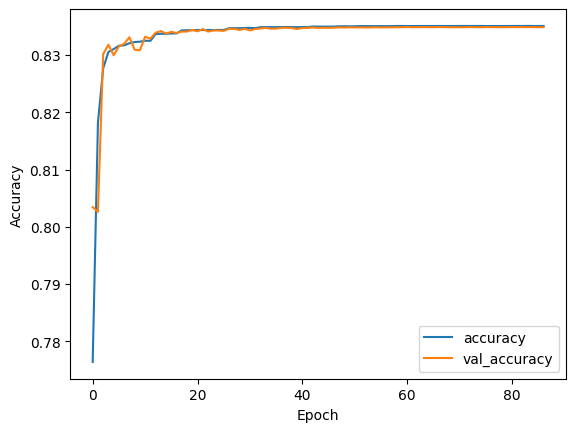

In [21]:
#plotting the accuracy of the second model
import matplotlib.pyplot as plt
plt.plot(history2.history['accuracy'], label='accuracy')
plt.plot(history2.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

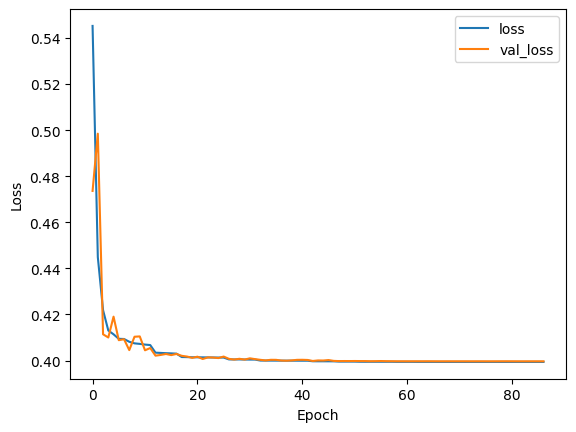

In [22]:
#plotting the loss over epoch for the second model
plt.plot(history2.history['loss'], label='loss')
plt.plot(history2.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [23]:
#save the second trained model
model2.save('../models/model_SimpleRNN_212.h5')